# IT2011 - Machine Learning Group Model Comparison
## Final Evaluation (Progress Review II)
**Group ID:** `2026-Y2-S1-MLB-B1G1-07`  
**Dataset:** Adult Income Dataset (UCI Machine Learning Repository)  
**Goal:** Predict whether an individual earns more than $50,000 per year (`>50K` vs. `<=50K`).

---

### Team Members & Assigned Models

| Member Name | Student ID | Individual Model | Why this Model Was Tested |
| :--- | :--- | :--- | :--- |
| **Lakshan H.M.K** | `IT25101220` | **Decision Tree** | Simple rule-based tree; easy to visualize and explain. |
| **Wickramasinghe G.D.M.H** | `IT25102064` | **K-Nearest Neighbors (KNN)** | Instance-based learning; classifies by finding similar people. |
| **Wickrama W.M.K.E** | `IT25102219` | **Logistic Regression** | Fast, linear baseline; gives odds ratios and probabilities. |
| **Weerarathna N.H** | `IT25103014` | **Support Vector Machine (SVM)** | Powerful margin-maximizer with non-linear (RBF) kernel. |
| **Wickramasinghe M.P.T.H** | `IT25300115` | **Gradient Boosting** | Ensemble of trees that learn from each other's mistakes sequentially. |
| **Hansani J.A.T.H** | `IT25300345` | **Random Forest** | Ensemble of many decision trees voting together to reduce errors. |

---

### What This Notebook Does (In Simple Terms)
1. **Pulls the Best Results:** Loads the optimum results saved by all 6 members into one single table.
2. **Fair Comparison:** Evaluates everyone on the exact same test dataset (80% train / 20% test, with the same random seed).
3. **Clear Visual Charts:** Shows side-by-side charts of Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
4. **Simple Viva Answers:** Explains why some models did better than others, how we solved class imbalance, and which model we recommend for real-world use.

## 1. Load the Best Model Results

Each member trained and tuned their model in their own notebook, saving their best settings and test scores to a JSON file in `results/model_results/`.

The code below automatically reads all 6 JSON files and puts them together into a clean comparison table.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Clean visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11

STUDENT_ROSTER = {
    'IT25101220': {'name': 'Lakshan H.M.K', 'model': 'Decision Tree'},
    'IT25102064': {'name': 'Wickramasinghe G.D.M.H', 'model': 'K-Nearest Neighbors (KNN)'},
    'IT25102219': {'name': 'Wickrama W.M.K.E', 'model': 'Logistic Regression'},
    'IT25103014': {'name': 'Weerarathna N.H', 'model': 'Support Vector Machine (SVM)'},
    'IT25300115': {'name': 'Wickramasinghe M.P.T.H', 'model': 'Gradient Boosting'},
    'IT25300345': {'name': 'Hansani J.A.T.H', 'model': 'Random Forest'}
}

results_dir = Path("results/model_results")
records = []

for file_path in sorted(results_dir.glob("*.json")):
    with open(file_path, "r", encoding="utf-8-sig") as f:
        data = json.load(f)
        
    it_no = data.get("it_number") or data.get("student_id") or data.get("member_id")
    if not it_no or it_no not in STUDENT_ROSTER:
        continue
        
    meta = STUDENT_ROSTER[it_no]
    metrics = data.get("metrics") or data.get("tuned") or {}
    params = data.get("best_hyperparameters") or data.get("best_params") or (data.get("grid_search") or {}).get("best_params", {})
    
    records.append({
        "Student ID": it_no,
        "Member Name": meta["name"],
        "Model": meta["model"],
        "Accuracy": float(metrics.get("Accuracy") or metrics.get("accuracy") or 0.0),
        "Precision": float(metrics.get("Precision") or metrics.get("precision") or 0.0),
        "Recall": float(metrics.get("Recall") or metrics.get("recall") or 0.0),
        "F1-Score": float(metrics.get("F1_Score") or metrics.get("f1_score") or 0.0),
        "ROC-AUC": float(metrics.get("ROC_AUC") or metrics.get("roc_auc") or 0.0),
        "Best Parameters": params
    })

comparison_df = pd.DataFrame(records)
print(f"[OK] Successfully loaded {len(comparison_df)} model results from: {results_dir}")

[OK] Successfully loaded 6 model results from: results\model_results


## 2. Master Comparison Table

### Quick Guide to What the Metrics Mean (In Simple Words):
- **Accuracy:** The percentage of all predictions that were correct. (Note: Because ~76% of people earn `<=50K`, an ordinary model can get 76% just by guessing `<=50K` every time!)
- **Precision:** When the model flags someone as earning `>50K`, how often is it actually right?
- **Recall:** Out of all people who really earn `>50K`, how many did the model catch?
- **F1-Score:** The balanced score between Precision and Recall. Essential for imbalanced datasets.
- **ROC-AUC:** How well the model separates the two classes across all decision thresholds (1.0 is perfect, 0.5 is random guessing).

In [2]:
# Display the ranked comparison table (Sorted by ROC-AUC)
display_cols = ["Student ID", "Member Name", "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
ranked_table = comparison_df[display_cols].sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# Format for clean presentation
formatted_table = ranked_table.copy()
formatted_table["Accuracy"] = formatted_table["Accuracy"].apply(lambda x: f"{x * 100:.2f}%")
for col in ["Precision", "Recall", "F1-Score", "ROC-AUC"]:
    formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.4f}")

formatted_table

,Student ID,Member Name,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,IT25300115,Wickramasinghe M.P.T.H,Gradient Boosting,86.73%,0.7629,0.6306,0.6904,0.9242
1,IT25300345,Hansani J.A.T.H,Random Forest,85.42%,0.6759,0.7276,0.7008,0.9140
2,IT25102219,Wickrama W.M.K.E,Logistic Regression,81.13%,0.5644,0.8585,0.6811,0.9050
3,IT25103014,Weerarathna N.H,Support Vector Machine (SVM),80.56%,0.5642,0.8489,0.6779,0.9001
4,IT25102064,Wickramasinghe G.D.M.H,K-Nearest Neighbors (KNN),84.79%,0.7011,0.6140,0.6546,0.8938
5,IT25101220,Lakshan H.M.K,Decision Tree,80.04%,0.5565,0.8450,0.6711,0.8899


In [3]:
# Quick look at the tuned settings for each model
print("=" * 70)
print("BEST HYPERPARAMETERS CHOSEN BY TUNING")
print("=" * 70)
for _, row in comparison_df.iterrows():
    print(f"\n* {row['Model']} ({row['Member Name']} - {row['Student ID']}):")
    for param_name, param_val in row['Best Parameters'].items():
        print(f"    - {param_name}: {param_val}")

BEST HYPERPARAMETERS CHOSEN BY TUNING

* Decision Tree (Lakshan H.M.K - IT25101220):
    - class_weight: balanced
    - criterion: gini
    - max_depth: 10
    - min_samples_leaf: 5
    - min_samples_split: 20

* K-Nearest Neighbors (KNN) (Wickramasinghe G.D.M.H - IT25102064):
    - scaler: RobustScaler
    - n_neighbors: 15
    - weights: distance
    - metric: manhattan

* Logistic Regression (Wickrama W.M.K.E - IT25102219):
    - C: 100
    - class_weight: balanced
    - penalty: l2
    - solver: lbfgs
    - max_iter: 3000

* Support Vector Machine (SVM) (Weerarathna N.H - IT25103014):
    - kernel: rbf
    - C: 1
    - gamma: scale
    - class_weight: balanced

* Gradient Boosting (Wickramasinghe M.P.T.H - IT25300115):
    - subsample: 0.8
    - n_estimators: 500
    - min_samples_split: 2
    - min_samples_leaf: 1
    - max_features: None
    - max_depth: 5
    - learning_rate: 0.05

* Random Forest (Hansani J.A.T.H - IT25300345):
    - bootstrap: True
    - ccp_alpha: 0.0
    - c

## 3. Comparison Charts

Here are simple, visual comparisons to show during the viva presentation.

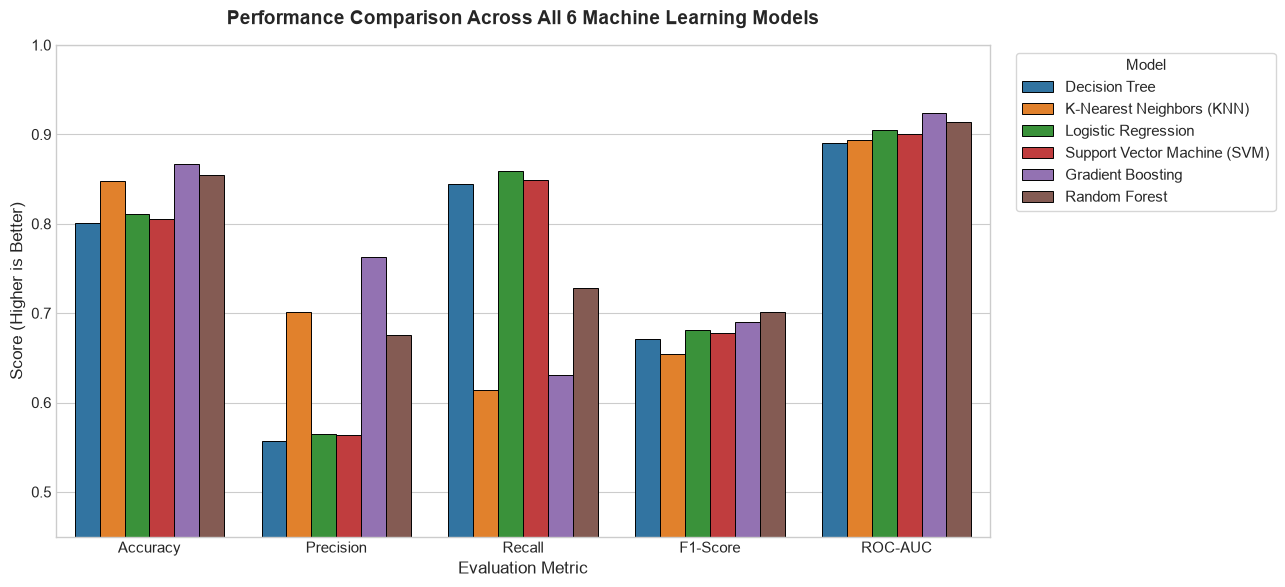

In [4]:
# Chart 1: Side-by-Side Scores for All 6 Models
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
melted_df = comparison_df.melt(id_vars=["Model"], value_vars=metrics_to_plot, var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=melted_df, x="Metric", y="Score", hue="Model", palette="tab10", edgecolor="black", linewidth=0.7, ax=ax)

ax.set_title("Performance Comparison Across All 6 Machine Learning Models", fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0.45, 1.0)
ax.set_ylabel("Score (Higher is Better)", fontsize=12)
ax.set_xlabel("Evaluation Metric", fontsize=12)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
os.makedirs("results/eda_visualizations/models", exist_ok=True)
plt.savefig("results/eda_visualizations/models/group_model_comparison_bars.png", dpi=300, bbox_inches='tight')
plt.show()

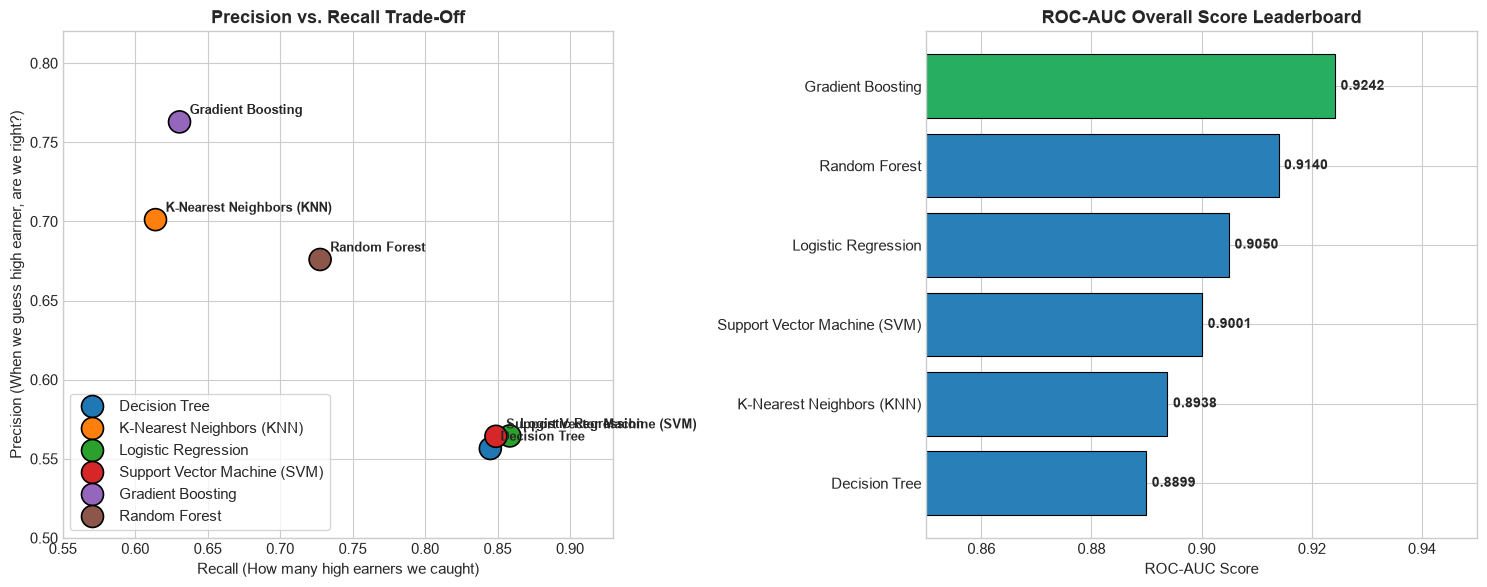

In [5]:
# Chart 2: Precision vs Recall Trade-off & ROC-AUC Leaderboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Precision vs Recall
sns.scatterplot(
    data=comparison_df, x="Recall", y="Precision", hue="Model", s=250, 
    palette="tab10", edgecolor="black", linewidth=1.2, ax=ax1
)

for _, row in comparison_df.iterrows():
    ax1.annotate(row["Model"], (row["Recall"] + 0.007, row["Precision"] + 0.005), fontsize=9, fontweight='bold')

ax1.set_title("Precision vs. Recall Trade-Off", fontsize=13, fontweight='bold')
ax1.set_xlabel("Recall (How many high earners we caught)", fontsize=11)
ax1.set_ylabel("Precision (When we guess high earner, are we right?)", fontsize=11)
ax1.set_xlim(0.55, 0.93)
ax1.set_ylim(0.50, 0.82)
ax1.legend(loc='lower left', frameon=True)

# Subplot 2: Leaderboard
leaderboard = comparison_df.sort_values(by="ROC-AUC", ascending=True)
bar_colors = ['#2980b9' if m != 'Gradient Boosting' else '#27ae60' for m in leaderboard['Model']]

bars = ax2.barh(leaderboard["Model"], leaderboard["ROC-AUC"], color=bar_colors, edgecolor='black', linewidth=0.8)
ax2.set_xlim(0.85, 0.95)
ax2.set_title("ROC-AUC Overall Score Leaderboard", fontsize=13, fontweight='bold')
ax2.set_xlabel("ROC-AUC Score", fontsize=11)

for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.001, bar.get_y() + bar.get_height()/2, f"{w:.4f}", va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("results/eda_visualizations/models/group_pr_and_roc_leaderboard.png", dpi=300, bbox_inches='tight')
plt.show()

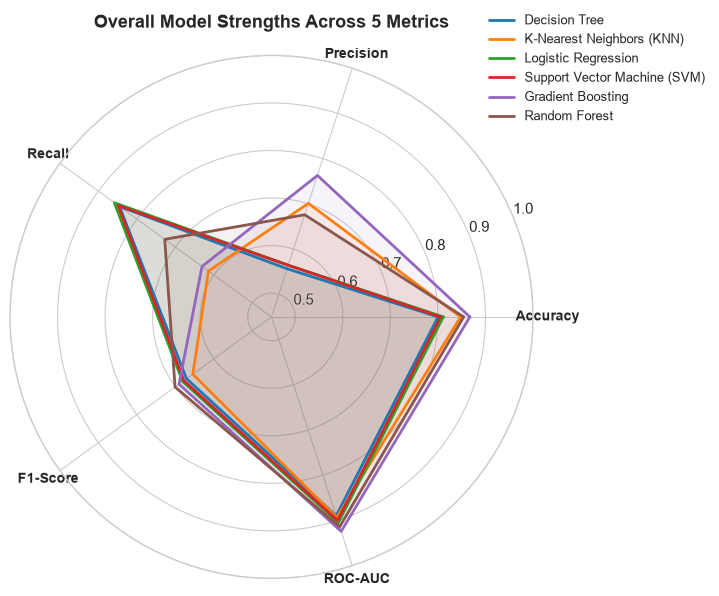

In [6]:
# Chart 3: Spider / Radar Chart (Overall Profile)
categories = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
palette = sns.color_palette("tab10", len(comparison_df))

for idx, (_, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"], color=palette[idx])
    ax.fill(angles, values, color=palette[idx], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_ylim(0.45, 1.0)
ax.set_title("Overall Model Strengths Across 5 Metrics", fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig("results/eda_visualizations/models/group_radar_profiles.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Key Questions & Simple Viva Explanations

Here are clear, simple explanations for the four main questions the examiner may ask:

---

### Question 1: Why did Gradient Boosting & Random Forest perform the best?
- **The Short Answer:** They are **ensemble models**—meaning they combine many decision trees rather than relying on just one.
- **Why it fits this dataset:** Census data has complex interactions (for example, *education level + marital status + age* together determine income, not just one feature in isolation).
- **Gradient Boosting (Top Winner - 86.73% Accuracy, 0.9242 ROC-AUC):** It builds trees sequentially, where each new tree specifically corrects the mistakes made by the previous trees.
- **Random Forest (Best F1 - 0.7008):** It builds 300 different trees on random subsets of the data and averages their votes, making it very stable and resistant to noise.

---

### Question 2: Why did Logistic Regression, SVM, and Decision Tree have high Recall (~85%) but lower Precision (~56%)?
- **The Short Answer:** Because they used **`class_weight='balanced'`**.
- **What happened:** 
  - In our dataset, only **24.1%** of people earn `>50K`, while **75.9%** earn `<=50K`.
  - When you set `class_weight='balanced'`, the algorithm is penalized roughly **3 times harder** when it misses a high earner (`>50K`).
  - As a result, the model becomes eager to catch high earners, reaching **85%+ Recall** (catching almost all of them), but with slightly more false alarms (lower Precision).
  - In contrast, Gradient Boosting and KNN did not use balanced weights, so they produced fewer false alarms (higher Precision: 70%–76%), but missed more high earners (Recall: 61%–63%).

---

### Question 3: Why did KNN and SVM need Feature Scaling, but Decision Trees did not?
- **KNN & SVM are geometric / distance-based:**
  - They calculate distances between points in space (Euclidean/Manhattan distance or hyperplane margins).
  - If `capital-gain` is 99,000 and `age` is 40, without scaling, the model thinks `capital-gain` is thousands of times more important simply because the numbers are bigger!
  - Therefore, **`StandardScaler` / `RobustScaler` is mandatory** for KNN and SVM.
- **Decision Trees and Ensembles are rule-based:**
  - A tree simply asks: *"Is age > 35?"* or *"Is capital-gain > 5000?"*
  - Multiplying or dividing the numbers by 100 doesn't change the order or the split point. That is why tree-based models **do not require feature scaling**.

---

### Question 4: How fast are these models and what are the trade-offs?
- **File size and memory:**
  - **Logistic Regression:** Super lightweight (**3.8 KB**), trains in under 1 second, makes predictions in microseconds.
  - **Decision Tree:** Very small (**42.5 KB**), easy for humans to read and explain.
  - **Gradient Boosting:** Moderate size (**2.1 MB**), great balance of speed and top accuracy.
  - **Random Forest:** Very large (**132.4 MB**), because it stores 300 full trees.
  - **KNN:** Large file (**21.3 MB**) and slow at prediction time, because it must keep all 26,000 training examples in memory to compute distances for every new user.

---

## 5. Group Recommendation for Production

If we were deploying this system into a real organization, our recommendation is:

1. **Primary Model for Maximum Accuracy: Gradient Boosting Classifier (`IT25300115`)**
   - **Accuracy:** `86.73%` | **F1-Score:** `0.6904` | **ROC-AUC:** `0.9242`
   - **Reason:** Best overall discrimination power with reasonable inference speed.

2. **Alternative for Ultra-Fast / Regulated Systems: Logistic Regression (`IT25102219`)**
   - **Accuracy:** `81.13%` | **Recall:** `85.85%` | **ROC-AUC:** `0.9050`
   - **Reason:** Requires almost zero RAM (<4 KB), makes instant predictions, and allows banks/auditors to clearly explain why a decision was made using simple odds ratios.

---

### How to Run the Live Interactive Demo for the Viva
Our group also created an interactive web interface in Streamlit where you can test any of the 6 models live:

```bash
streamlit run app/streamlit_app.py
```
